# 구독 서비스의 성장 지표 확인하기 — MRR 분석 실습

본문에서 다룬 MRR 분석을 직접 진행해 보겠습니다. 스토어마다 내려받을 수 있는 구독 데이터가
조금씩 다르긴 하지만, MRR을 분해하고 GRR과 NRR을 살펴보는 분석의 틀은 스토어 종류와 무관하게
활용할 수 있습니다. Google Play Sales Report와 비슷한 형태의 결제 로그 하나만 가지고
파이프라인을 처음부터 끝까지 재현합니다.

- **6.3.2.** `order_number`에서 유저를 식별하고 (6.2.4.1)
- **6.3.3.** renew와 reactivation을 구분한 뒤 (6.2.4.3)
- **6.3.4.** 월별 MRR을 new / renew / reactivation / expansion / contraction / churn으로 분해하고 (6.2.3, 6.2.4.2)
- **6.3.5.** GRR과 NRR로 매출 유지력을 진단하고 (6.2.4.6)
- **6.3.6.** 데이터에 심어 둔 정답(월 이탈률 5%)을 복원하며 LTV 어림식으로 연결합니다.

책에는 없지만 노트북에서만 다루는 검증·심화 구간은 **[노트북 보충]**으로 표시했습니다
(결제 간격 확인, MRR 항등식 검증, 구독자 수 단위 분해 — 6.2.4.7).
체험(Trial) 흐름, 연구독 안분(retained MRR), 환불 처리는 본문 설명으로 갈음하고 실습에서는 다루지 않습니다.


## 6.3.1. 실습용 데이터 준비

아래 두 셀은 의존성을 설치하고 라이브러리와 차트 폰트를 설정합니다. 데이터가 없다면 먼저
터미널에서 `python generate_data.py` 를 실행해 예시 데이터(`data/subscription_sales.csv`)를
만들어 주세요. 그다음 노트북 환경을 구성하고 실습을 시작합니다.


In [ ]:
%pip install -q -r requirements.txt

In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# 차트에 한글이 섞여도 깨지지 않도록 폰트 설정 (라벨 자체는 영어를 사용)
if sys.platform.startswith("win"):
    plt.rcParams["font.family"] = "Malgun Gothic"
elif sys.platform == "darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# DuckDB 인메모리 연결 하나를 만들어 노트북 전체에서 재사용합니다.
con = duckdb.connect()
con.execute("CREATE TABLE sales AS "
            "SELECT * FROM read_csv_auto('data/subscription_sales.csv')")

### 결제 로그 살펴보기

실습에 사용하는 테이블은 단 하나입니다. Google Play의 Sales Report와 비슷한 형태의 결제
로그로, 18개월 동안 발생한 10,653건의 결제 기록이 담겨 있습니다. 유저를 식별할 수 있는 ID
칼럼은 없고, 대신 주문번호를 이용해서 결제 순서를 구분할 수 있다고 가정하겠습니다. 첫 결제는
`order_number`에 suffix가 없고, 갱신 결제부터 `..1`, `..2`가 붙습니다. 상품은 월 4,900원의
basic과 월 9,900원의 plus 두 가지입니다.


In [4]:
display(con.execute("SELECT count(*) AS rows, min(order_charged_date) AS first, "
                    "max(order_charged_date) AS last FROM sales").df())
con.execute("SELECT * FROM sales ORDER BY order_charged_date LIMIT 5").df()

,rows,first,last
0,10653,2025-01-01,2026-06-28


,order_number,order_charged_date,product_id,sales_amount_krw
0,GPA.3473-2940-6316-10023,2025-01-01,monthly_basic,4900
1,GPA.4592-1953-7554-10053,2025-01-02,monthly_basic,4900
2,GPA.7136-4072-6031-10032,2025-01-02,monthly_basic,4900
3,GPA.9603-9106-3123-10049,2025-01-02,monthly_basic,4900
4,GPA.5376-7591-3453-10048,2025-01-03,monthly_plus,9900


## 6.3.2. order_number에서 유저 식별하기

모든 분석의 출발점은 결제 건들을 유저 단위로 묶는 것입니다. 주문번호의 `'..'` 앞부분(prefix)이
같으면 동일 유저라고 가정하겠습니다. suffix는 0, 1, null 등 여러 케이스로 나타날 수 있으니,
suffix를 믿기보다는 `row_number()`로 결제일 순서에 따라 누적 결제 회차(`order_cnt`)를 직접 세는
것이 안전합니다.

이 유저 식별 결과는 다음 단계들이 계속 재사용하므로 orders 뷰로 만들어 둡니다.


In [5]:
con.execute("""
    CREATE OR REPLACE VIEW orders AS
    SELECT
        split_part(order_number, '..', 1)  AS pid
      , order_charged_date
      , product_id
      , sales_amount_krw
      , row_number() OVER (PARTITION BY split_part(order_number, '..', 1)
                           ORDER BY order_charged_date) AS order_cnt
    FROM sales
""")
orders = con.execute("SELECT * FROM orders").df()
n_orders = orders.groupby("pid").size()
print(f"유저 수: {orders.pid.nunique():,}명 / 결제 건수: {len(orders):,}건")
print(f"유저별 결제 횟수: 최소 {n_orders.min()}회 ~ 최대 {n_orders.max()}회")
n_orders.value_counts().sort_index()

유저 수: 1,653명 / 결제 건수: 10,653건
유저별 결제 횟수: 최소 1회 ~ 최대 18회


1     198
2     179
3     169
4     149
5     134
6     126
7     114
8      93
9      85
10     72
11     75
12     62
13     45
14     41
15     35
16     29
17     22
18     25
Name: count, dtype: int64

## 6.3.3. renew와 reactivation 구분하기

6.2.4.3에서 연속된 재결제(renew)와 공백 후 재결제(reactivation)는 구분하는 것이 바람직하다고
이야기했습니다. `LAG()`로 직전 결제일을 가져와서, 간격이 32일 미만이면(한 주기 약 30일에 여유를
둔 기준) renew, 그 이상이면 reactivation으로 분류합니다. 분류 결과를 classified 뷰로 만들어 두면,
6.3.4의 MRR 분해 쿼리가 그대로 가져다 쓸 수 있습니다.

> **[내 데이터 적용]** 결제 주기가 월 단위가 아니면 32일 임계값을 주기에 맞게 바꿉니다.
> 연구독처럼 주기가 긴 상품은 이 방식이 맞지 않으므로 6.2.4.4를 참고하세요.


In [6]:
con.execute("""
    CREATE OR REPLACE VIEW classified AS
    SELECT *
         , CASE WHEN order_cnt = 1 THEN 'new'
                WHEN order_charged_date - prev_date < 32
                     THEN 'renew'
                ELSE 'reactivation' END AS pay_type
    FROM (SELECT *
               , lag(order_charged_date) OVER (
                     PARTITION BY pid ORDER BY order_charged_date) AS prev_date
          FROM orders)
""")
classified = con.execute("SELECT * FROM classified").df()
classified.pay_type.value_counts()

pay_type
renew           8961
new             1653
reactivation      39
Name: count, dtype: int64

### [노트북 보충] 결제 간격으로 분류 검증

분류가 잘 됐는지 결제 간격의 분포로 확인해 봅니다.
renew는 28~31일(월 주기)에 몰려 있고, reactivation은 최소 한 달 이상의 공백 뒤에 나타나야 정상입니다.


In [7]:
gap = (pd.to_datetime(classified.order_charged_date)
       - pd.to_datetime(classified.prev_date)).dt.days
for t in ["renew", "reactivation"]:
    g = gap[classified.pay_type == t]
    print(f"{t:14s} 간격: {g.min():.0f} ~ {g.max():.0f}일 (중앙값 {g.median():.0f}일)")

renew          간격: 28 ~ 31일 (중앙값 31일)
reactivation   간격: 44 ~ 396일 (중앙값 160일)


## 6.3.4. 월별 MRR 분해하기

유저×월 단위로 결제 데이터를 모은 뒤 전월과 **FULL OUTER JOIN** 하면, 각 유저가 세 가지 상태 중
하나로 나뉩니다.

- 이번 달과 전월 모두 결제 → 계속 구독 (재결제 금액이 늘어난 부분은 expansion, 줄어든 부분은 contraction, 남은 유지분은 renew. 6.2.3의 renew MRR에서 contraction을 뺀 값)
- 이번 달에만 결제 → new 또는 reactivation
- 전월에만 결제 → churn

여기서 renew는 6.2.3의 renew MRR(전월 MRR − churn MRR)에서 contraction까지 뺀 '그대로 유지된
금액'입니다. 다운그레이드 분을 이미 덜어냈기 때문에, 이 실습의 결과 표에서는
MRR = renew + new + reactivation + expansion으로 딱 떨어집니다. 6.2.3의 식에 맞추려면 renew에
contraction을 다시 더하면 됩니다.

같은 쿼리를 `sql/mrr_breakdown.sql` 파일로도 넣어 두었습니다.


먼저 유저×월 단위 집계를 monthly 뷰로 만들어 둡니다.


In [8]:
con.execute("""
    CREATE OR REPLACE VIEW monthly AS
    -- 유저×월 집계: 같은 달의 여러 결제(월중 플랜 변경 등)를 한 행으로
    SELECT
        pid
      , date_trunc('month', order_charged_date) AS month
      , sum(sales_amount_krw) AS amt
      -- pay_type 우선순위: new > reactivation > renew (알파벳순과 우연히 일치)
      , min(pay_type) AS pay_type
    FROM classified
    GROUP BY pid, month
""")

이렇게 만든 monthly 뷰를 자기 자신과 한 달 어긋나게 붙여, 이번 달(c)과 전월(p)을 짝지은 paired 뷰로 만들어 둡니다.


In [9]:
con.execute("""
    CREATE OR REPLACE VIEW paired AS
    SELECT
        coalesce(c.month, p.month + INTERVAL 1 MONTH) AS month
      , c.amt AS amt             -- 이번 달 결제액 (없으면 NULL = 이탈)
      , p.amt AS prev_amt        -- 전월 결제액 (없으면 NULL = 신규/복귀)
      , c.amt - p.amt AS delta   -- 증감분 (expansion/contraction 계산용)
      , c.pay_type
      , c.amt IS NOT NULL AND p.amt IS NOT NULL AS stayed  -- 두 달 모두 결제
    FROM monthly c
    FULL OUTER JOIN monthly p
      ON c.pid = p.pid AND p.month = c.month - INTERVAL 1 MONTH
""")

이제 paired 뷰를 집계하면 여섯 가지 MRR 요소가 한 번에 나옵니다. 세 번 반복될 뻔한 '두 달 모두 결제' 조건은 stayed 플래그 하나로 정리됩니다.

In [10]:
mrr = con.execute("""
    SELECT
        month
      , sum(amt)                                            AS mrr
      , sum(CASE pay_type WHEN 'new' THEN amt END)          AS new_mrr
      , sum(CASE pay_type WHEN 'reactivation' THEN amt END) AS reactivation_mrr
      , sum(CASE WHEN stayed THEN least(amt, prev_amt) END) AS renew_mrr
      , sum(CASE WHEN stayed THEN greatest(delta, 0) END)   AS expansion_mrr
      , sum(CASE WHEN stayed THEN greatest(-delta, 0) END)  AS contraction_mrr
      , sum(CASE WHEN amt IS NULL THEN prev_amt END)        AS churn_mrr
      , sum(prev_amt)                                       AS baseline_mrr
    FROM paired
    -- 마지막 월 다음에 생기는 '유령 월'(전월만 있는 행) 제거
    WHERE month <= (SELECT max(month) FROM monthly)
    GROUP BY month
    ORDER BY month
""").df().fillna(0)
mrr["month"] = pd.to_datetime(mrr["month"]).dt.to_period("M").astype(str)
mrr = mrr.iloc[1:].reset_index(drop=True)  # 첫 달은 전월이 없어 제외
mrr.tail(6)

,month,mrr,new_mrr,reactivation_mrr,renew_mrr,expansion_mrr,contraction_mrr,churn_mrr,baseline_mrr
11,2026-01,5039000.0,659100.0,44500.0,4285400.0,50000.0,10000.0,196800.0,4492200.0
12,2026-02,5680800.0,783500.0,14700.0,4797600.0,85000.0,5000.0,236400.0,5039000.0
13,2026-03,6108800.0,753000.0,29500.0,5301300.0,25000.0,5000.0,374500.0,5680800.0
14,2026-04,6561000.0,712800.0,34400.0,5783800.0,30000.0,20000.0,305000.0,6108800.0
15,2026-05,7136700.0,747000.0,29500.0,6270200.0,90000.0,25000.0,265800.0,6561000.0
16,2026-06,7608900.0,811700.0,49300.0,6707900.0,40000.0,25000.0,403800.0,7136700.0


### [노트북 보충] MRR 항등식 검증

6.2.3의 수식이 실제로 성립하는지 확인해 봅니다.

**MRR = 전월 MRR(Baseline) + new + reactivation + expansion − contraction − churn**

실습의 renew는 contraction을 뺀 유지분이지만, 이 식은 renew가 아니라 Baseline을 출발점으로
쓰기 때문에 그대로 성립합니다.


In [11]:
check = (mrr.baseline_mrr + mrr.new_mrr + mrr.reactivation_mrr
         + mrr.expansion_mrr - mrr.contraction_mrr - mrr.churn_mrr)
print("항등식 최대 오차:", (mrr.mrr - check).abs().max(), "원")

항등식 최대 오차: 0.0 원


위 표를 바탕으로, MRR을 차트로 분해해 보겠습니다. renew 위에 expansion, reactivation, new를 쌓고 churn은 음수 막대로 표시합니다.


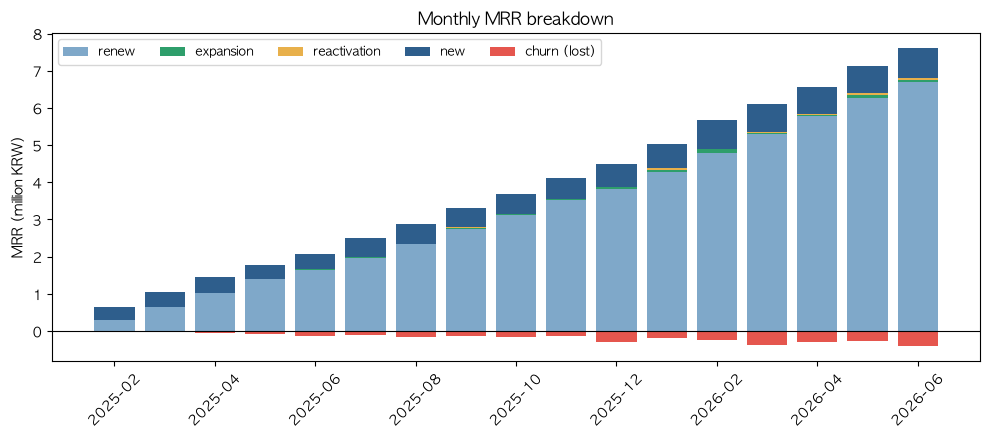

In [12]:
# MRR 스택 차트 — renew 위에 expansion/reactivation/new, churn은 음수로 표시
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(mrr))
bottom = np.zeros(len(mrr))
colors = {"renew_mrr": "#7FA8C9", "expansion_mrr": "#2E9E6B",
          "reactivation_mrr": "#E8B04B", "new_mrr": "#2E5E8C"}
for col, c in colors.items():
    ax.bar(x, mrr[col] / 1e6, bottom=bottom, color=c,
           label=col.replace("_mrr", ""))
    bottom += mrr[col].to_numpy() / 1e6
ax.bar(x, -mrr.churn_mrr / 1e6, color="#E5564E", label="churn (lost)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x[::2]); ax.set_xticklabels(mrr.month[::2], rotation=45)
ax.set_ylabel("MRR (million KRW)")
ax.set_title("Monthly MRR breakdown")
ax.legend(ncol=5, fontsize=9)
plt.tight_layout(); plt.show()

매달 MRR의 대부분은 renew(기존 구독자의 재결제)가 받치고 있고, 그 위에 new가 성장분을 쌓습니다.
아래로 뻗은 빨간 막대(churn)와 위의 new를 비교하면 구독 MRR의 순증 여부를 확인할 수 있습니다.


## 6.3.5. GRR과 NRR - 방어력과 성장력 확인

6.2.4.6의 두 공식을 그대로 적용해서 GRR과 NRR을 구해보겠습니다. 6.3.4에서 만든 `mrr` 테이블에
계산에 필요한 데이터가 이미 다 갖춰져 있습니다. Baseline은 '전월부터 있던 기존 매출'입니다.

- GRR = (Baseline − churn − contraction) / Baseline
- NRR = (Baseline − churn − contraction + expansion) / Baseline


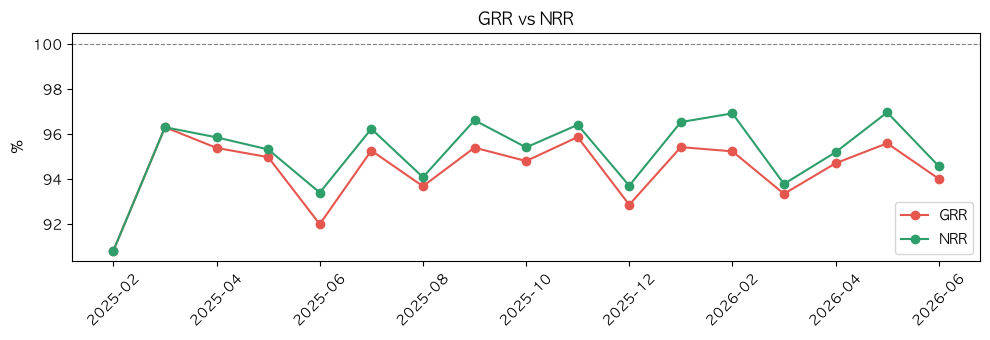

GRR 평균 94.4% / NRR 평균 95.2% / 갭 +0.73%p


In [13]:
kept = mrr.baseline_mrr - mrr.churn_mrr - mrr.contraction_mrr
mrr["grr"] = kept / mrr.baseline_mrr
mrr["nrr"] = mrr.grr + mrr.expansion_mrr / mrr.baseline_mrr

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(mrr.month, mrr.grr * 100, marker="o", color="#E5564E", label="GRR")
ax.plot(mrr.month, mrr.nrr * 100, marker="o", color="#2E9E6B", label="NRR")
ax.axhline(100, color="gray", ls="--", lw=0.8)
ax.set_ylabel("%"); ax.set_title("GRR vs NRR")
ax.set_xticks(range(0, len(mrr), 2)); ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout(); plt.show()
gap = (mrr.nrr - mrr.grr).mean()
print(f"GRR 평균 {mrr.grr.mean():.1%} / NRR 평균 {mrr.nrr.mean():.1%}"
      f" / 갭 {gap:+.2%}p")

이 그래프에서는 GRR이 대체로 92~96%, NRR이 93~97% 수준을 유지하고 있어 기존 고객의 반복 매출이
비교적 안정적으로 유지되고 있음을 알 수 있습니다. 대부분의 기간에 NRR이 GRR보다 높다는 점은
업그레이드, 추가 좌석, 부가 기능 이용, 사용량 증가 등을 통한 확장 매출이 발생하고 있음을
보여줍니다. 다만 두 지표가 비슷한 흐름으로 등락하고, NRR도 100%를 넘지 못하고 있어 확장 매출이
이탈과 다운그레이드로 인한 매출 감소를 완전히 상쇄하지는 못하는 상황입니다. 특히 GRR이
상대적으로 낮아지는 시기에는 고객 이탈이나 다운그레이드의 원인을 살펴보고, 동시에 확장 매출이
발생하는 고객군과 이용 패턴을 분석해 기존 고객 기반의 성장 가능성을 높일 필요가 있습니다.


### [노트북 보충] 사람 수와 돈을 헷갈리지 않기 - 구독자 수 분해

같은 FULL OUTER JOIN 로직을 '구독자 수' 단위로 반복합니다. 6.2.4.7에서 강조했듯,
**업그레이드/다운그레이드는 매출(expansion/contraction)만 바꿀 뿐 구독자 수는 바꾸지 않습니다.**
쿼리는 `sql/subscriber_counts.sql`에 있습니다.


In [14]:
query = open("sql/subscriber_counts.sql", encoding="utf-8").read()
subs = con.execute(query).df().fillna(0)
subs["month"] = pd.to_datetime(subs["month"]).dt.to_period("M").astype(str)
subs = subs.iloc[1:].reset_index(drop=True)

# 구독자 수 항등식: 이번 달 구독자 = 전월 구독자 + new + reactivation - churned
prev_subs = subs.subscribers.shift(1)
check = prev_subs + subs.new_subs + subs.reactivation_subs - subs.churned_subs
print("구독자 수 항등식 오차(첫 달 제외):", (subs.subscribers - check).abs().iloc[1:].max())
subs.tail(4)

구독자 수 항등식 오차(첫 달 제외): 0.0


,month,subscribers,new_subs,reactivation_subs,churned_subs
13,2026-03,962,120,5,55
14,2026-04,1040,122,6,50
15,2026-05,1133,130,5,42
16,2026-06,1211,133,7,62


매출 수식에는 expansion/contraction 항이 있었지만, 구독자 수 수식에는 없습니다.
그런데도 두 항등식이 모두 정확히 성립합니다 — 지금 집계하는 지표가 '사람 수'인지 '돈'인지에 따라
써야 하는 수식이 달라진다는 것을 데이터로 확인한 셈입니다.

## 6.3.6. 이탈률과 구독 LTV

이 실습 데이터를 최초 생성할 때의 로직에는 **월 이탈률 5%**라는 가정이 들어가 있었습니다
(`generate_data.py`에서 모든 구독자가 매달 5% 확률로 갱신을 멈추도록 설정). 우리가 분해한
churn MRR로 이탈률을 역산했을 때 실제로 5%에 가까운 수치가 나올까요? 아래 코드로 검증해
보겠습니다. (6.2.3의 churn rate 수식)


In [15]:
# 초기 몇 달은 코호트가 어려 churn 모수가 작으므로, 안정화된 구간으로 계산
stable = mrr[mrr.month >= "2025-04"]
churn_rate = (stable.churn_mrr / stable.baseline_mrr).mean()
print(f"복원된 월 churn rate : {churn_rate:.1%}  (가정한 값: 5%)")

lifetime_m = 1 / churn_rate
arpu = classified.sales_amount_krw.mean()
print(f"기대 구독 유지 기간  : {lifetime_m:.1f}개월  (≈ 1 / {churn_rate:.3f})")
print(f"인당 월매출(ARPU)    : {arpu:,.0f}원")
print(f"구독자 1인 LTV 어림  : {arpu / churn_rate:,.0f}원  (ARPU ÷ churn rate)")

복원된 월 churn rate : 5.2%  (가정한 값: 5%)
기대 구독 유지 기간  : 19.2개월  (≈ 1 / 0.052)
인당 월매출(ARPU)    : 6,237원
구독자 1인 LTV 어림  : 120,030원  (ARPU ÷ churn rate)


실습 데이터를 생성할 때 설정한 월 이탈 확률은 5%였고, 분석 결과 복원한 월 매출 기준 이탈률은
5.2%로 비슷하게 나타났습니다. 월 이탈 확률이 일정하다고 가정하면, 기대 구독 유지 기간은 이탈률의
역수로 계산할 수 있습니다. 매달 5.2%의 확률로 이탈하는 구독자의 기대 유지 기간은 약
19.2개월입니다. 여기에 구독자당 월평균 매출(ARPU)을 곱하면 구독자 한 명이 구독 기간 동안
발생시킬 매출, 즉 매출 기준 LTV를 근사할 수 있습니다. (이 계산은 이탈률과 ARPU가 일정하다는
가정에 기반한 단순 추정치라는 점을 유의해야 합니다.)

이탈률을 5.2%에서 4.2%로 1%p 낮추고 ARPU가 동일하게 유지된다고 가정하면, 기대 구독 유지
기간은 약 19.2개월에서 23.8개월로 늘어나고 매출 기준 LTV는 약 120,000원에서 148,500원으로
24%가량 증가합니다. 이 간단한 계산은 이탈률의 작은 변화가 고객의 장기적인 매출 기여에 얼마나
큰 차이를 만들 수 있는지 보여줍니다.

결제 로그에서 출발해 유저 식별, renew/reactivation 분류, MRR 분해, GRR·NRR 진단을 거쳐
이탈률과 LTV까지 살펴보았습니다. 이처럼 개별 결제 데이터를 체계적으로 분류하고 연결하면, 단순한
매출 집계를 넘어 구독 비즈니스의 구독 유지율과 성장 가능성을 더 입체적으로 이해할 수 있습니다.

## 마치며

결제 로그 하나에서 시작해 유저 식별 → renew/reactivation 분류 → MRR 분해 → GRR/NRR 진단 →
구독자 수 검증 → LTV 어림까지, 6.2의 파이프라인을 그대로 재현했습니다.
실무에서는 여기에 체험(Trial) 전환, 연구독 안분, 환불, 비자발적 이탈 처리가 얹어집니다 —
각각의 개념과 주의점은 6.1, 6.2.4.4, 6.2.4.5를 참고하세요.

> **[내 데이터 적용]** 스토어 리포트를 쓴다면 금액이 gross(수수료 차감 전)인지 net인지부터 확인하고,
> 결제 주기에 맞춰 6.3.3의 32일 임계값을 조정하는 것부터 시작하면 됩니다.
